In [2]:
import pandas as pd
import numpy as np
import datetime as dt

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error

# Load in Data

* Range of data: 1/1/2022 to 3/22/2024
* Train/validation range: 1/1/2022 to 1/14/2023
    * 0.8/0.2 random train-validation split
* Test range: 1/15/2024-3/22/2024

In [3]:
data = pd.read_csv("data.csv")

In [4]:
train = data.loc[:71423]
train.head(3)

,Unnamed: 0,date,time,power,workday
0,0,2022-01-01,0.00,0.0,0
1,1,2022-01-01,0.25,0.0,0
2,2,2022-01-01,0.50,0.0,0


In [5]:
test = data.loc[71424:]
test.head(3)

,Unnamed: 0,date,time,power,workday
71424,71424,2024-01-15,0.00,-1.367699e-07,0
71425,71425,2024-01-15,0.25,-1.367699e-07,0
71426,71426,2024-01-15,0.50,-1.367699e-07,0


In [6]:
x_dim = 32

def get_X_y(df, lookahead):
    power = df['power'].to_numpy()
    workday = df['workday'].to_numpy()
    time = df['time'].to_numpy()
    
    power_chunks = [power[i:i+x_dim] for i in range(0, len(power) - 32, lookahead)]
    workday = [workday[i] for i in range(0, len(power) - 32, lookahead)]
    time = [time[i] for i in range(0, len(power) - 32, lookahead)]
    
    y = [power[i:i+lookahead] for i in range(32, len(power), lookahead)]

    X = pd.DataFrame(data={"power" : power_chunks, "workday" : workday, "time" : time})
    y = pd.DataFrame(data={"power" : y})

    X = X.reset_index()
    y = y.reset_index()

    return X, y

In [7]:
LOOKAHEAD = 16

X_trainval, y_trainval = get_X_y(train, LOOKAHEAD)
X_test, y_test = get_X_y(test, LOOKAHEAD)

In [8]:
class PercentileKNNRegressor:
    def __init__(self, n_neighbors=5, percentile=50):
        self.n_neighbors = n_neighbors
        self.percentile = percentile
        self.knn = KNeighborsRegressor(n_neighbors=n_neighbors)

    def fit(self, X, y):
        self.knn.fit(X, y)

    def predict(self, X):
        distances, indices = self.knn.kneighbors(X)
        nearest_neighbors_values = self.knn._y[indices]

        nth_percentile_values = np.percentile(nearest_neighbors_values, self.percentile, axis=1)

        return nth_percentile_values

# Tuning K with Validation Set

In [9]:
X_train, X_val, y_train, y_val = train_test_split(X_trainval, y_trainval, test_size=0.2, random_state=42)

mses = []
wmses = []

alpha = 0.2

for k in range(1, 21):
    models = {}
    for t in [0, 4, 8, 12, 16, 20]:
        for w in [0, 1]:
            knn_regressor = PercentileKNNRegressor(n_neighbors=k, percentile=90)
            mask = (X_train['time'] == t) & (X_train['workday'] == w)
            X_input = X_train[mask]['power']  
            y_input = y_train[mask]['power']  
            X_input = np.array([i for i in X_input])
            y_input = np.array([i for i in y_input])
            knn_regressor.fit(X_input, y_input)
            models[(t, w)] = knn_regressor


    forecasts = []
    for index, row in X_val.iterrows():
        forecasts.append(models[(row['time'], row['workday'])].predict(np.array(row['power']).reshape(1, -1)))

    forecast = np.array([f[0] for f in forecasts]).flatten()
    real = np.array([a for a in y_val['power'].to_numpy()]).flatten()

    mse = mean_squared_error(forecast, real)

    weights = alpha ** (1 + np.sign(forecast - real))
    wmse = mean_squared_error(forecast, real, sample_weight=weights)

    mses.append(mse)
    wmses.append(wmse)
    
    print(f"k={k}\tMSE={mse}\tWMSE={wmse}")

k=1	MSE=29.132379030915526	WMSE=33.12170381921696
k=2	MSE=30.061408645515513	WMSE=23.00800361826063
k=3	MSE=31.284756709374083	WMSE=22.51631356110755
k=4	MSE=31.695798850969226	WMSE=22.47999372273082
k=5	MSE=32.352025860784465	WMSE=21.355304763270617
k=6	MSE=32.86756189590332	WMSE=21.546228949948006
k=7	MSE=33.568647723326734	WMSE=21.194512187598843
k=8	MSE=33.51727857493946	WMSE=22.684418692131654
k=9	MSE=33.807101538851626	WMSE=22.645975541820036
k=10	MSE=34.58320308111621	WMSE=23.275705858343983
k=11	MSE=36.1584275524085	WMSE=22.025709484003244
k=12	MSE=36.56199407507205	WMSE=20.922937430666924
k=13	MSE=37.1820231307853	WMSE=21.216805017054256
k=14	MSE=37.31394206438326	WMSE=21.477032003806844
k=15	MSE=37.84939602203378	WMSE=21.63870169423595
k=16	MSE=37.98132936050595	WMSE=22.675243905350435
k=17	MSE=38.393767297891934	WMSE=23.68091754434284
k=18	MSE=38.78047573811855	WMSE=24.37406179638684
k=19	MSE=39.173290926179185	WMSE=24.93922069974012
k=20	MSE=39.30813988090654	WMSE=25.316060

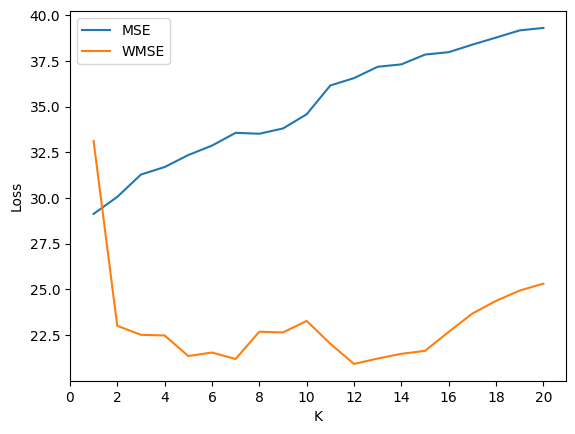

In [10]:
plt.plot(range(1, 21), mses, label="MSE")
plt.plot(range(1, 21), wmses, label="WMSE")
plt.legend()
plt.xlabel("K")
plt.xticks(range(0, 21, 2))
plt.ylabel("Loss");

# Final Model
* k = 3
* Train with all data between 1/1/2022 and 1/14/2024
* Test with data between 1/15/2024 and 3/22/2024

In [16]:
models = {}


for t in [0, 4, 8, 12, 16, 20]:
    for w in [0, 1]:
        knn_regressor = PercentileKNNRegressor(n_neighbors=10, percentile=90)
        mask = (X_trainval['time'] == t) & (X_trainval['workday'] == w)
        X_input = X_trainval[mask]['power']  
        y_input = y_trainval[mask]['power']  
        X_input = np.array([i for i in X_input])
        y_input = np.array([i for i in y_input])
        knn_regressor.fit(X_input, y_input)
        models[(t, w)] = knn_regressor

In [17]:
forecasts = []
for index, row in X_test.iterrows():
    forecasts.append(models[(row['time'], row['workday'])].predict(np.array(row['power']).reshape(1, -1)))

forecast = np.array([f[0] for f in forecasts]).flatten()
real = np.array([a for a in y_test['power'].to_numpy()]).flatten()

mse = mean_squared_error(forecast, real)

weights = alpha ** (1 + np.sign(forecast - real))
wmse = mean_squared_error(forecast, real, sample_weight=weights)

print(f"MSE={mse}\tWMSE={wmse}")

MSE=40.21344382967242	WMSE=25.58911155450324


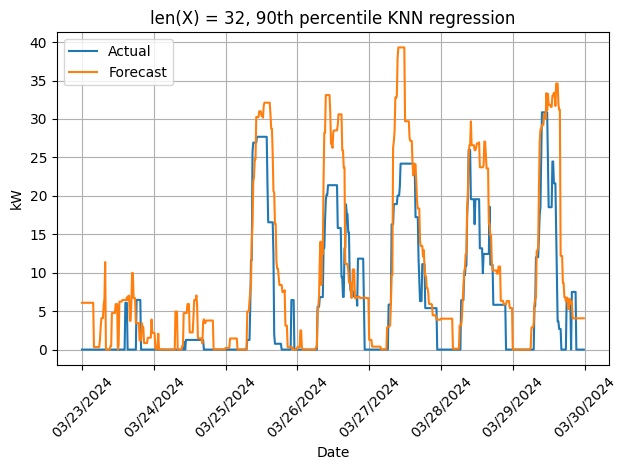

In [23]:
dates = pd.date_range(start='2024-03-23', periods=672, freq='15T')


plt.plot(dates, real[-96*7:], label="Actual")
plt.plot(dates, forecast[-96*7:], label="Forecast")

# Set x-axis labels format
plt.gca().xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%m/%d/%Y'))

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

plt.xlabel('Date')
plt.ylabel('kW')
plt.title("len(X) = 32, 90th percentile KNN regression")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Sanity Check

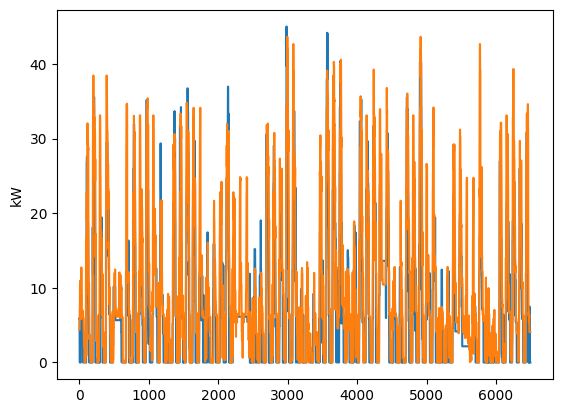

In [19]:
all_forecast = np.array([f[0] for f in forecasts]).flatten()
all_real = np.array([a for a in y_test['power'].to_numpy()]).flatten()

plt.plot(real, label="Actual")
plt.plot(forecast, label="Forecast")
plt.ylabel("kW");

In [20]:
sum(forecast > real) / len(real)

0.8149630541871922